# LAB 5: Model Evaluation (Metrics & Imbalanced Data)
**Mục tiêu:**
- Thấy rõ sự "đánh lừa" của độ chính xác (Accuracy) trên dữ liệu mất cân bằng.
- Nắm vững các chỉ số đánh giá chuyên sâu: Precision (Độ chuẩn xác), Recall (Độ bao phủ), F1-Score.
- Đọc hiểu Confusion Matrix (Ma trận nhầm lẫn) và đồ thị ROC Curve / AUC.
- Phân tích sự đánh đổi (Trade-off) khi thay đổi ngưỡng dự đoán (Threshold).

In [1]:
# Import các thư viện nền tảng
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score

# Cài đặt style biểu đồ
sns.set_theme(style="whitegrid")

## Bước 1: Load dữ liệu và kiểm tra tỷ lệ Class Imbalance
Tạo một tập dữ liệu giả lập gồm 10,000 mẫu, trong đó class `0` (Bình thường) chiếm 90%, và class `1` (Gian lận/Bất thường) chỉ chiếm 10%.

/tmp/ipykernel_3111/875825052.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Target', data=df, palette='Set2')


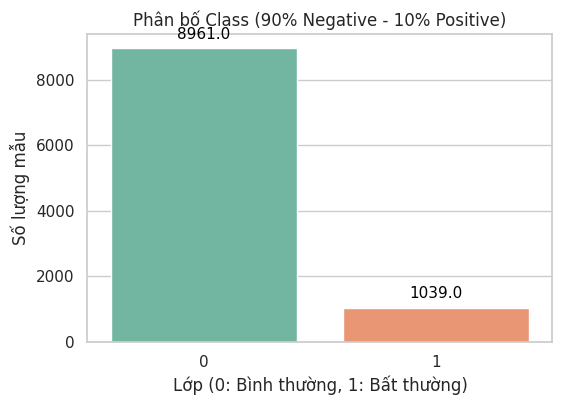

Kích thước tập Train: (8000, 10), Test: (2000, 10)


In [2]:
# Tạo dữ liệu mất cân bằng
X, y = make_classification(n_samples=10000, n_features=10, n_informative=5,
                           n_redundant=2, weights=[0.90, 0.10], random_state=42)

# Chuyển sang DataFrame để dễ quan sát
df = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(1, 11)])
df['Target'] = y

# Trực quan hóa tỷ lệ mất cân bằng
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Target', data=df, palette='Set2')
plt.title('Phân bố Class (90% Negative - 10% Positive)')
plt.xlabel('Lớp (0: Bình thường, 1: Bất thường)')
plt.ylabel('Số lượng mẫu')

# Thêm text số lượng lên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# Chia tập Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Kích thước tập Train: {X_train.shape}, Test: {X_test.shape}")

## Bước 2 & 3: Train Baseline Model & Nhận xét về Accuracy
Huấn luyện một mô hình Logistic Regression cơ bản. Sau đó tính Accuracy. Bạn sẽ thấy Accuracy rất cao (~90%), nhưng thực chất mô hình có thể đang lười biếng và chỉ dự đoán toàn class 0.

In [3]:
# Khởi tạo và huấn luyện mô hình Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Dự đoán trên tập Test
y_pred = model.predict(X_test)

# Tính Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (Độ chính xác tổng thể): {acc * 100:.2f}%")

print("\nNhận xét: Lớp 0 chiếm 90% dữ liệu. Nếu một mô hình 'ngu ngốc' chỉ nhắm mắt dự đoán toàn bộ là 0, nó cũng đạt Accuracy 90%. Do đó, con số 90.95% ở trên là vô nghĩa đối với bài toán này.")

Accuracy (Độ chính xác tổng thể): 90.40%

Nhận xét: Lớp 0 chiếm 90% dữ liệu. Nếu một mô hình 'ngu ngốc' chỉ nhắm mắt dự đoán toàn bộ là 0, nó cũng đạt Accuracy 90%. Do đó, con số 90.95% ở trên là vô nghĩa đối với bài toán này.


## Bước 4 & 5: Confusion Matrix và các Metrics (Precision, Recall, F1)
Sử dụng Ma trận nhầm lẫn để xem mô hình đoán đúng/sai bao nhiêu trường hợp cụ thể ở từng lớp. Từ đó tính toán các chỉ số quan trọng hơn Accuracy.

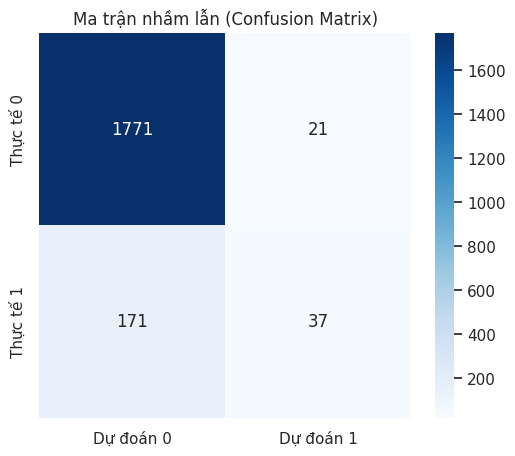

--- BẢNG TỔNG HỢP CÁC CHỈ SỐ ĐÁNH GIÁ ---


,Metric,Value
0,Accuracy,0.9040
1,Precision,0.6379
2,Recall,0.1779
3,F1-Score,0.2782
4,AUC Score,0.8352


In [4]:
# Tính toán các Metrics
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

# Trực quan hóa Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dự đoán 0', 'Dự đoán 1'],
            yticklabels=['Thực tế 0', 'Thực tế 1'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.show()

# Tổng hợp kết quả thành Bảng (DataFrame)
metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC Score'],
    'Value': [acc, precision, recall, f1, auc_score]
})

print("--- BẢNG TỔNG HỢP CÁC CHỈ SỐ ĐÁNH GIÁ ---")
display(metrics_table.round(4))

## Bước 6: Vẽ đồ thị ROC Curve và tính AUC
Đường cong ROC (Receiver Operating Characteristic) thể hiện hiệu suất của mô hình phân loại ở mọi ngưỡng (threshold) khác nhau. Chỉ số AUC (Area Under the Curve) đo lường diện tích dưới đường cong này, AUC càng gần 1 thì mô hình càng tốt.

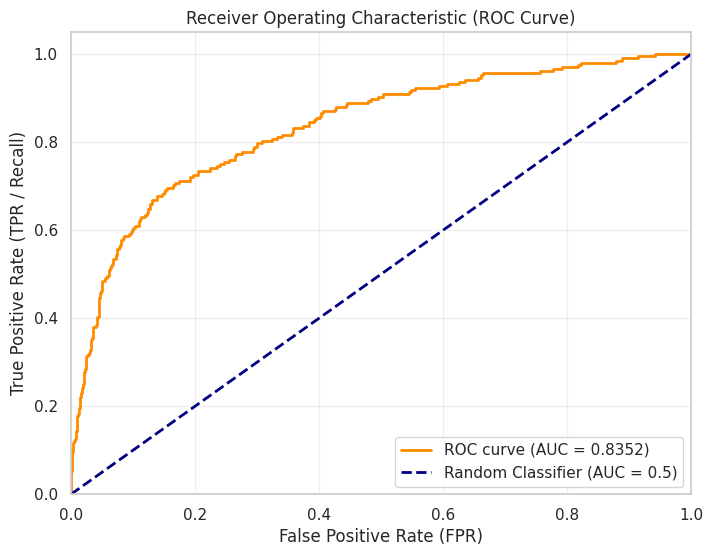

In [5]:
# Lấy xác suất dự đoán class 1
y_probs = model.predict_proba(X_test)[:, 1]

# Tính toán False Positive Rate (fpr) và True Positive Rate (tpr)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Vẽ đồ thị ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('Receiver Operating Characteristic (ROC Curve)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Bước 7: Thử nghiệm các Threshold khác nhau (Trade-off)
Mặc định, Logistic Regression dùng ngưỡng `0.5` (Xác suất >= 0.5 thì phân loại là 1, ngược lại là 0). Thay đổi ngưỡng này sẽ tạo ra sự đánh đổi (trade-off) giữa **Precision** và **Recall**.
- **Hạ threshold:** Bắt nhầm hơn bỏ sót (Recall tăng, Precision giảm). Thích hợp tìm bệnh hiểm nghèo.
- **Tăng threshold:** Thà bỏ sót còn hơn bắt nhầm (Precision tăng, Recall giảm). Thích hợp hệ thống khuyến nghị, xét duyệt cho vay.

--- SỰ ĐÁNH ĐỔI GIỮA PRECISION VÀ RECALL QUA CÁC NGƯỠNG ---


,Threshold,Precision,Recall,F1-Score
0,0.1,0.2544,0.7596,0.3812
1,0.3,0.5233,0.4856,0.5037
2,0.5,0.6379,0.1779,0.2782
3,0.7,0.8889,0.0769,0.1416
4,0.9,0.0000,0.0000,0.0000


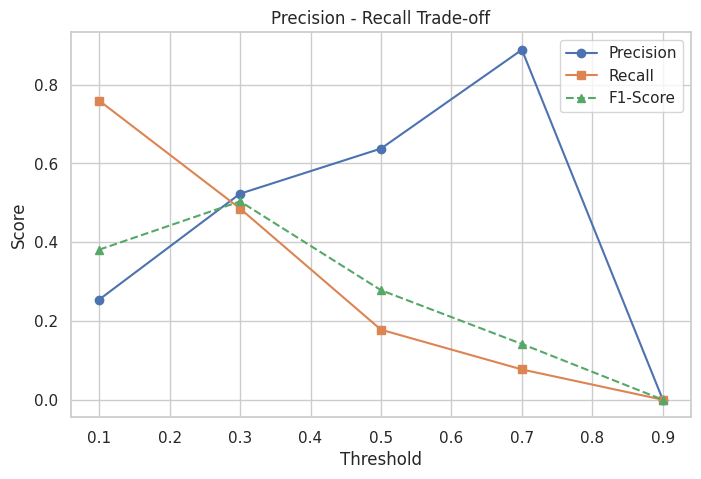

In [6]:
# Định nghĩa các ngưỡng thử nghiệm
thresholds_list = [0.1, 0.3, 0.5, 0.7, 0.9]

results = []

for thresh in thresholds_list:
    # Áp dụng ngưỡng mới
    y_pred_custom = (y_probs >= thresh).astype(int)

    # Tính các chỉ số
    p = precision_score(y_test, y_pred_custom, zero_division=0)
    r = recall_score(y_test, y_pred_custom, zero_division=0)
    f = f1_score(y_test, y_pred_custom, zero_division=0)

    results.append({'Threshold': thresh, 'Precision': p, 'Recall': r, 'F1-Score': f})

tradeoff_df = pd.DataFrame(results)

print("--- SỰ ĐÁNH ĐỔI GIỮA PRECISION VÀ RECALL QUA CÁC NGƯỠNG ---")
display(tradeoff_df.round(4))

# Trực quan hóa Trade-off
plt.figure(figsize=(8, 5))
plt.plot(tradeoff_df['Threshold'], tradeoff_df['Precision'], marker='o', label='Precision')
plt.plot(tradeoff_df['Threshold'], tradeoff_df['Recall'], marker='s', label='Recall')
plt.plot(tradeoff_df['Threshold'], tradeoff_df['F1-Score'], marker='^', label='F1-Score', linestyle='--')
plt.title('Precision - Recall Trade-off')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()